This notebook contains a simple example of how to fine-tune a HuggingFace model.  We examine different fine-tuning configurations using LoRA, a parameter-efficient mechanism to fine-tune a model that updates existing (some subset of) model weights using low-rank matrix updates. 

Lightweight fine-tuning is important for adapting foundation models, because it allows us to modify a foundation model for unique problemm space without requiring substantial compute.

In HuggingFace, parameter-efficient model fine-tuning is easy to do. 

**Let's get started!**

Let's begin by loading a pretrained HF model in the Distilbert family, which is old but fast and lightweight for our purposes. We will be experimenting later with a dataset with 4 classes, so we set num_labels=4.

In [50]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

model_name = "distilbert-base-uncased"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

print(f"Loaded model: {model_name}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded model: distilbert-base-uncased


Next, we load the AG News dataset. The AG News dataset is a popular text classification benchmark 
consisting of news articles categorized into 4 classes: World, Sports, Business, and Sci/Tech. 
It contains around 120,000 training samples and 7,600 test samples, with each example including a short news title and description. 
It is commonly used to evaluate models on topic classification tasks, like we're about to do!

For the sake of speeding things up, we will use a subset of the data for training and testing.

In [51]:
'''
Load and preprocess a dataset
'''

def preprocess_function(examples):
    # 'text' column contains the news article content
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)


# Load the AG News dataset (4-class news classification)
dataset = load_dataset("ag_news")

# Optional: Use a smaller subset to reduce computation
small_train = dataset["train"].shuffle(seed=42).select(range(10000))
small_test = dataset["test"].shuffle(seed=42).select(range(1000))

# Tokenize the subsets
tokenized_train = small_train.map(preprocess_function, batched=True)
tokenized_test = small_test.map(preprocess_function, batched=True)

# Set format for PyTorch
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"Tokenized train size: {len(tokenized_train)}")
print(f"Tokenized test size: {len(tokenized_test)}")

Tokenized train size: 10000
Tokenized test size: 1000


Let's begin by evaluating the pretrained model. 

In [52]:
'''
Evaluate the pretrained model
'''

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate
import numpy as np

# Load accuracy metric
accuracy = evaluate.load("accuracy")

# Define a compute_metrics function for the Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Set training arguments (minimal since we're just evaluating)
training_args = TrainingArguments(
    output_dir="./results",
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    do_train=False,  # No training yet
    do_eval=True,
)

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# Evaluate the pretrained model
base_results = trainer.evaluate()

# Print the evaluation results
print("Pretrained model performance on AG News:")
print(base_results)


Pretrained model performance on AG News:
{'eval_loss': 1.394287109375, 'eval_model_preparation_time': 0.002, 'eval_accuracy': 0.205, 'eval_runtime': 2.7365, 'eval_samples_per_second': 365.428, 'eval_steps_per_second': 11.694}


We see an evaluation accuracy of .267 - not so good, but not surprising given the classification head is randomly initialized.  For a 4-class problem with equal class label distribution, this is basically as good as random guessing. Let's see if we can do better without training the whole model from scratch.

We begin by creating a parameter efficient fine tuning (PEFT) model using the LoRA concept. We are going to adapt the Q and V modules in the self-attention layers of the model.

In [53]:
'''Create a PEFT model'''


from peft import get_peft_model, LoraConfig, TaskType

# Define the PEFT configuration
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,         # Sequence classification
    inference_mode=False,               # Set to False for training
    r=8,                                # Rank of LoRA update matrices
    lora_alpha=32,                      # Scaling factor
    lora_dropout=0.1,                   # Dropout for regularization
    target_modules = ["q_lin", "k_lin", "v_lin"]
)

# Apply PEFT to the existing model
peft_model = get_peft_model(model, peft_config)

# (Optional) Print trainable parameters summary
peft_model.print_trainable_parameters()



trainable params: 814,852 || all params: 67,771,400 || trainable%: 1.2024


As we can see, the entire model has more than 67 million parameters. Newer models are much, much larger. So, it makes sense to try to 
fine-tune a subset of the model, as we will now do.

Let's train the model with PEFT using LoRA. Depending on hardware available, this may take up to several minutes.

In [54]:
# Define training args and train model

from transformers import TrainingArguments
from transformers import default_data_collator

training_args = TrainingArguments(
    output_dir="./peft-distilbert-agnews",
    num_train_epochs=1,                       # train for at least 1 epoch
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    save_strategy="no",
    logging_dir="./logs",
    logging_steps=20,
    load_best_model_at_end=False,
    report_to="none",
)

from transformers import Trainer

class PeftTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Remove keys not expected by the model
        inputs.pop("num_items_in_batch", None)
        return super().compute_loss(model, inputs, return_outputs)


def custom_collator(features):
    # Use default collator
    batch = default_data_collator(features)
    # Remove keys that the model doesn't expect
    batch.pop("num_items_in_batch", None)
    return batch

trainer = PeftTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=custom_collator,
)

trainer.train()




/tmp/ipykernel_1702474/4217149245.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `PeftTrainer.__init__`. Use `processing_class` instead.
  trainer = PeftTrainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
20,1.356100
40,1.255400
60,1.077200
80,0.884700
100,0.666500
120,0.590200
140,0.517700
160,0.465700
180,0.407800
200,0.426000


TrainOutput(global_step=625, training_loss=0.47404358005523684, metrics={'train_runtime': 62.3644, 'train_samples_per_second': 160.348, 'train_steps_per_second': 10.022, 'total_flos': 337438371840000.0, 'train_loss': 0.47404358005523684, 'epoch': 1.0})

Let's save the model.

In [55]:
'''
Save the peft model
'''

output_dir = "./peft-distilbert-lora"

# Save the fine-tuned PEFT model
peft_model.save_pretrained(output_dir)

print(f"PEFT model saved to: {output_dir}")

PEFT model saved to: ./peft-distilbert-lora


Note the saved model (which contains only the weights to be modified) is < 4 MB - a small fraction of how much it would take to store the entire model's weights. 

Next, let's load the saved model from disk.

In [56]:
'''
Load the saved PEFT model
'''

from peft import PeftModel, PeftConfig

# Path to the saved adapter directory
saved_peft_path = "./peft-distilbert-lora"

# Load PEFT config
peft_config = PeftConfig.from_pretrained(saved_peft_path)

# Load the base model (must match the original base model)
base_model = AutoModelForSequenceClassification.from_pretrained(
    peft_config.base_model_name_or_path,
    num_labels=4  # Must match what you used during training
)

# Combine base model with PEFT adapters
peft_model = PeftModel.from_pretrained(base_model, saved_peft_path)

# (Optional) Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_config.base_model_name_or_path)

print("PEFT model successfully loaded.")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT model successfully loaded.


Let's evaluate the model on the test set.

In [57]:
# Run evaluation
eval_trainer = Trainer(
    model=peft_model,
    args=training_args,  # same TrainingArguments as before
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

peft_results = eval_trainer.evaluate()


# Print evaluation results
print("Evaluation Results of Fine-Tuned PEFT Model:")
for k, v in peft_results.items():
    print(f"{k}: {v:.4f}")

/tmp/ipykernel_1702474/2734267101.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  eval_trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Evaluation Results of Fine-Tuned PEFT Model:
eval_loss: 0.3410
eval_model_preparation_time: 0.0036
eval_accuracy: 0.8820
eval_runtime: 3.1641
eval_samples_per_second: 316.0430
eval_steps_per_second: 10.1130


We plot relative improvement of the PEFT-based model to the original one.

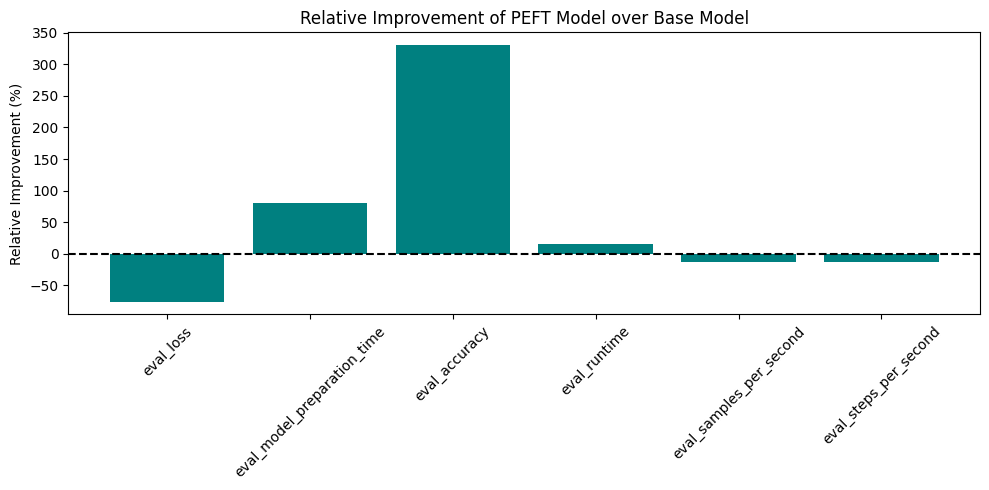

In [58]:
import matplotlib.pyplot as plt

metrics = list(base_results.keys())
metrics = [m for m in metrics if isinstance(base_results[m], (int, float))]

rel_improvements = []
for m in metrics:
    base_val = base_results[m]
    peft_val = peft_results[m]
    if base_val != 0:
        improvement = ((peft_val - base_val) / abs(base_val)) * 100
    else:
        improvement = 0
    rel_improvements.append(improvement)

plt.figure(figsize=(10, 5))
plt.bar(metrics, rel_improvements, color='teal')
plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.ylabel("Relative Improvement (%)")
plt.title("Relative Improvement of PEFT Model over Base Model")
plt.tight_layout()
plt.show()


We see a large increase in accuracy.

Next, we conduct a more systematic exploration using different hyperparameters for LoRA, varying the rank and alpha parameters. r is the rank (lower rank means fewer parameters), while alpha is the relative contribution of the low-rank update (lower alpha means we stay closer to the original model). Next, we define some hyperparameter settings.

In [63]:
from peft import get_peft_model, LoraConfig, TaskType

configs = [
    LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=8,            # LoRA rank
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["k_lin", "q_lin", "v_lin"],  # specify LoRA target modules
    ),
    LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["k_lin", "q_lin", "v_lin"],  # specify LoRA target modules
    ),
    LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=4,
        lora_alpha=8,
        lora_dropout=0.05,
        target_modules=["k_lin", "q_lin", "v_lin"],  # specify LoRA target modules
    ),
]


We will train on several configurations as above. This will take some time!

In [ ]:
results = {}



for i, peft_config in enumerate(configs):
    print(f"\n--- Training with PEFT config #{i+1} ---")
    
    # Reload base model to start fresh
    base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)
    peft_model = get_peft_model(base_model, peft_config)

    
    
    # Trainer setup (reuse training_args and other components)
    trainer = PeftTrainer(
        model=peft_model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        data_collator=custom_collator,
    )
    
    trainer.train()
    
    # Evaluate after training
    eval_results = trainer.evaluate()
    results[f"config_{i+1}"] = {
        "config": peft_config,
        "metrics": eval_results,
    }
    print(f"Eval results for config #{i+1}: {eval_results}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Training with PEFT config #1 ---


/tmp/ipykernel_1702474/1455155299.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `PeftTrainer.__init__`. Use `processing_class` instead.
  trainer = PeftTrainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
20,1.357300
40,1.266000
60,1.129700
80,1.005900
100,0.818700
120,0.684100
140,0.567600
160,0.502100
180,0.431000
200,0.439600


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Step,Training Loss
20,1.356100
40,1.254800
60,1.073200
80,0.873700
100,0.653400
120,0.581300
140,0.514200
160,0.461000
180,0.403500
200,0.419700


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Eval results for config #2: {'eval_loss': 0.33962109684944153, 'eval_accuracy': 0.884, 'eval_runtime': 3.0779, 'eval_samples_per_second': 324.901, 'eval_steps_per_second': 10.397, 'epoch': 1.0}

--- Training with PEFT config #3 ---


/tmp/ipykernel_1702474/1455155299.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `PeftTrainer.__init__`. Use `processing_class` instead.
  trainer = PeftTrainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
20,1.357700
40,1.270200
60,1.151500
80,1.064800
100,0.929700
120,0.817400
140,0.684600
160,0.587100
180,0.485900
200,0.475700


Let's plot the results

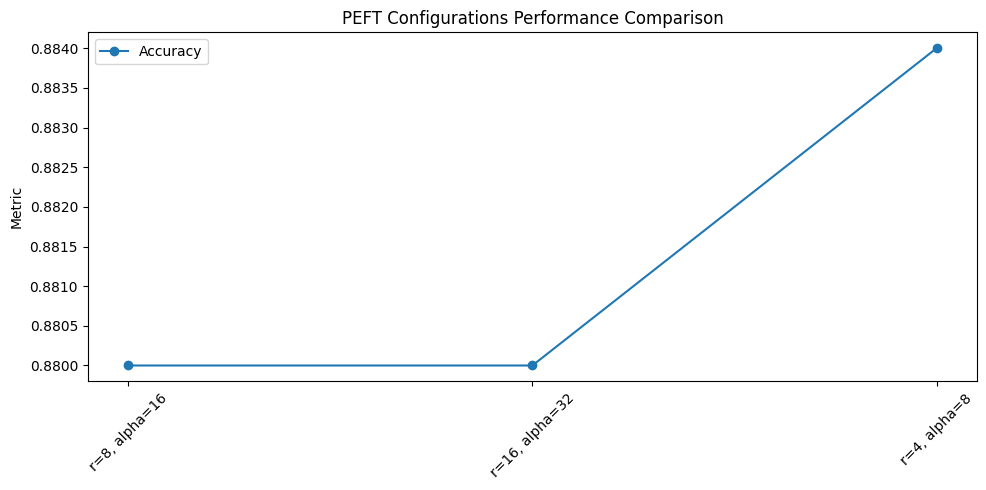

In [62]:
import matplotlib.pyplot as plt

configs_labels = [f"r={c.r}, alpha={c.lora_alpha}" for c in configs]
accuracies = [results[f"config_{i+1}"]["metrics"]["eval_accuracy"] for i in range(len(configs))]
#f1_scores = [results[f"config_{i+1}"]["metrics"]["eval_f1"] for i in range(len(configs))]

x = range(len(configs))

plt.figure(figsize=(10,5))
plt.plot(x, accuracies, marker='o', label="Accuracy")
#plt.plot(x, f1_scores, marker='x', label="F1 Score")
plt.xticks(x, configs_labels, rotation=45)
plt.title("PEFT Configurations Performance Comparison")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.show()


Results are similar across all hyperparameters tried - of course, more careful testing is required. It does look like we may be overtraining with our current number of epochs and amount of training data.

But, at first glance, it appears our model performs well across several settings. 

And that's it!  PEFT in HF is easy and let's us leverage powerful foundation models to quickly tackle our own domain-specific problems. 
It can also complement RAG-based solutions to create a powerful, domain-adapted LLM based solution!